# component_study.ipynb
Tuned directional-coupler beam splitter layout generation

Output:
  gds/tuned_beam_splitter.gds
Units:
   gdsfactory uses micrometers by default.

## Imports and folders

In [1]:
from pathlib import Path

import numpy as np
import gdsfactory as gf

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
GDS_DIR = Path("gds")
GDS_DIR.mkdir(exist_ok=True)

output_gds_path = GDS_DIR / "tuned_beam_splitter.gds"

print(f"GDS output folder: {GDS_DIR.resolve()}")
print(f"Output GDS path:    {output_gds_path.resolve()}")

GDS output folder: C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds
Output GDS path:    C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\tuned_beam_splitter.gds


## Main imported design parameters

In [2]:
# Waveguide geometry
wg_width_um = 0.300          # 500 nm waveguide width
gap_um = 0.250               # 150 nm edge-to-edge coupling gap

# Coupling region
coupling_length_um = 2.677    # tuned 50/50 coupling length from supermode analysis

pitch = 4

# S-bend routing
sbend_x_um = 25.0            # horizontal length of each S-bend
sbend_y_um = pitch/2 - gap_um/2 - wg_width_um/2  # vertical S-bend offset

# Small straight extensions before/after the S-bends
input_straight_um = 5.0
output_straight_um = 5.0

# Layout layers
WG_LAYER = (1, 0)            # silicon waveguide layer
LABEL_LAYER = (10, 0)        # text label layer

# Sampling resolution for smooth polygons
num_sbend_points = 101
num_straight_points = 20

print("Beam splitter parameters:")
print(f"  waveguide width     = {wg_width_um:.3f} um")
print(f"  coupling gap        = {gap_um:.3f} um")
print(f"  coupling length     = {coupling_length_um:.3f} um")
print(f"  S-bend x length     = {sbend_x_um:.3f} um")
print(f"  S-bend y offset     = {sbend_y_um:.3f} um")

Beam splitter parameters:
  waveguide width     = 0.300 um
  coupling gap        = 0.250 um
  coupling length     = 2.677 um
  S-bend x length     = 25.000 um
  S-bend y offset     = 1.725 um


## Helper functions for smooth S-bend polygon generation

In [3]:
def smoothstep(t: np.ndarray) -> np.ndarray:
    """
    Smooth interpolation from 0 to 1 with zero slope at both ends.

    y(t) = 3t^2 - 2t^3
    """
    return 3 * t**2 - 2 * t**3


def make_sbend_centerline(
    x0: float,
    x1: float,
    y0: float,
    y1: float,
    npoints: int = 101,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns a smooth S-bend centerline between (x0, y0) and (x1, y1).

    The x coordinate changes linearly.
    The y coordinate follows a cubic smoothstep profile.
    """
    t = np.linspace(0, 1, npoints)
    x = x0 + (x1 - x0) * t
    y = y0 + (y1 - y0) * smoothstep(t)
    return x, y


def make_straight_centerline(
    x0: float,
    x1: float,
    y: float,
    npoints: int = 20,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns a straight centerline from x0 to x1 at fixed y.
    """
    x = np.linspace(x0, x1, npoints)
    yarr = np.full_like(x, y)
    return x, yarr


def centerline_to_polygon(
    x: np.ndarray,
    y: np.ndarray,
    width: float,
) -> list[tuple[float, float]]:
    """
    Converts a sampled centerline into a strip-waveguide polygon.

    The polygon is generated by offsetting the centerline by +/- width/2
    along the local normal direction.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 2:
        raise ValueError("Centerline must contain at least two points.")

    dx = np.gradient(x)
    dy = np.gradient(y)

    ds = np.sqrt(dx**2 + dy**2)
    if np.any(ds == 0):
        raise ValueError("Centerline contains repeated points that create zero-length segments.")

    # Unit normal vector
    nx = -dy / ds
    ny = dx / ds

    half_width = width / 2

    x_upper = x + half_width * nx
    y_upper = y + half_width * ny

    x_lower = x - half_width * nx
    y_lower = y - half_width * ny

    polygon_x = np.concatenate([x_upper, x_lower[::-1]])
    polygon_y = np.concatenate([y_upper, y_lower[::-1]])

    return list(zip(polygon_x, polygon_y))

## Main beam-splitter component function

In [4]:
def make_tuned_beam_splitter(
    wg_width: float = 0.5,
    gap: float = 0.15,
    coupling_length: float = 20.0,
    sbend_x: float = 40.0,
    sbend_y: float = 10.0,
    input_straight: float = 5.0,
    output_straight: float = 5.0,
    wg_layer: tuple[int, int] = (1, 0),
    label_layer: tuple[int, int] = (10, 0),
    num_sbend_points: int = 101,
    num_straight_points: int = 20,
    add_labels: bool = True,
) -> gf.Component:
    """
    Creates a 2x2 directional-coupler beam splitter with S-bend fanout.

    Parameters
    ----------
    wg_width:
        Waveguide width in um.

    gap:
        Edge-to-edge gap between the two waveguides in the coupling region, in um.

    coupling_length:
        Straight coupling-region length in um.

    sbend_x:
        Horizontal length of each input/output S-bend in um.

    sbend_y:
        Vertical fanout offset from the coupling-region centerlines in um.

    input_straight:
        Input straight length before the left S-bends in um.

    output_straight:
        Output straight length after the right S-bends in um.

    Returns
    -------
    gf.Component
        Tuned beam-splitter layout.
    """

    c = gf.Component("tuned_beam_splitter")

    # --------------------------------------------------------
    # Coupling-region centerline positions
    # --------------------------------------------------------
    center_sep = wg_width + gap

    y_top_coupler = +center_sep / 2
    y_bot_coupler = -center_sep / 2

    y_top_port = y_top_coupler + sbend_y
    y_bot_port = y_bot_coupler - sbend_y

    # --------------------------------------------------------
    # x positions
    # --------------------------------------------------------
    x_input = 0.0
    x_sbend_left_start = input_straight
    x_coupler_start = x_sbend_left_start + sbend_x
    x_coupler_end = x_coupler_start + coupling_length
    x_sbend_right_end = x_coupler_end + sbend_x
    x_output = x_sbend_right_end + output_straight

    # --------------------------------------------------------
    # Top waveguide centerline
    # --------------------------------------------------------
    x1, y1 = make_straight_centerline(
        x_input,
        x_sbend_left_start,
        y_top_port,
        npoints=num_straight_points,
    )

    x2, y2 = make_sbend_centerline(
        x_sbend_left_start,
        x_coupler_start,
        y_top_port,
        y_top_coupler,
        npoints=num_sbend_points,
    )

    x3, y3 = make_straight_centerline(
        x_coupler_start,
        x_coupler_end,
        y_top_coupler,
        npoints=num_straight_points,
    )

    x4, y4 = make_sbend_centerline(
        x_coupler_end,
        x_sbend_right_end,
        y_top_coupler,
        y_top_port,
        npoints=num_sbend_points,
    )

    x5, y5 = make_straight_centerline(
        x_sbend_right_end,
        x_output,
        y_top_port,
        npoints=num_straight_points,
    )

    x_top = np.concatenate([x1, x2[1:], x3[1:], x4[1:], x5[1:]])
    y_top = np.concatenate([y1, y2[1:], y3[1:], y4[1:], y5[1:]])

    # --------------------------------------------------------
    # Bottom waveguide centerline
    # --------------------------------------------------------
    x1, y1 = make_straight_centerline(
        x_input,
        x_sbend_left_start,
        y_bot_port,
        npoints=num_straight_points,
    )

    x2, y2 = make_sbend_centerline(
        x_sbend_left_start,
        x_coupler_start,
        y_bot_port,
        y_bot_coupler,
        npoints=num_sbend_points,
    )

    x3, y3 = make_straight_centerline(
        x_coupler_start,
        x_coupler_end,
        y_bot_coupler,
        npoints=num_straight_points,
    )

    x4, y4 = make_sbend_centerline(
        x_coupler_end,
        x_sbend_right_end,
        y_bot_coupler,
        y_bot_port,
        npoints=num_sbend_points,
    )

    x5, y5 = make_straight_centerline(
        x_sbend_right_end,
        x_output,
        y_bot_port,
        npoints=num_straight_points,
    )

    x_bot = np.concatenate([x1, x2[1:], x3[1:], x4[1:], x5[1:]])
    y_bot = np.concatenate([y1, y2[1:], y3[1:], y4[1:], y5[1:]])

    # --------------------------------------------------------
    # Convert centerlines to polygons
    # --------------------------------------------------------
    top_polygon = centerline_to_polygon(x_top, y_top, wg_width)
    bot_polygon = centerline_to_polygon(x_bot, y_bot, wg_width)

    c.add_polygon(top_polygon, layer=wg_layer)
    c.add_polygon(bot_polygon, layer=wg_layer)

    # --------------------------------------------------------
    # Add optical ports
    # --------------------------------------------------------
    c.add_port(
        name="o1",
        center=(x_input, y_top_port),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="o2",
        center=(x_input, y_bot_port),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="o3",
        center=(x_output, y_top_port),
        width=wg_width,
        orientation=0,
        layer=wg_layer,
    )

    c.add_port(
        name="o4",
        center=(x_output, y_bot_port),
        width=wg_width,
        orientation=0,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Optional labels
    # --------------------------------------------------------
    if add_labels:
        label_offset_y = 1.0

        c.add_label(
            text="o1_in_top",
            position=(x_input, y_top_port + label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text="o2_in_bot",
            position=(x_input, y_bot_port - label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text="o3_out_top",
            position=(x_output, y_top_port + label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text="o4_out_bot",
            position=(x_output, y_bot_port - label_offset_y),
            layer=label_layer,
        )

        c.add_label(
            text=(
                f"DC_w{wg_width:.3f}_g{gap:.3f}_"
                f"Lc{coupling_length:.3f}_"
                f"Sx{sbend_x:.1f}_Sy{sbend_y:.1f}"
            ),
            position=(0.5 * x_output, 0.0),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Store useful metadata
    # --------------------------------------------------------
    c.info["wg_width_um"] = wg_width
    c.info["gap_um"] = gap
    c.info["coupling_length_um"] = coupling_length
    c.info["sbend_x_um"] = sbend_x
    c.info["sbend_y_um"] = sbend_y
    c.info["center_to_center_gap_um"] = center_sep
    c.info["total_length_um"] = x_output
    c.info["input_pitch_um"] = abs(y_top_port - y_bot_port)
    c.info["coupling_pitch_um"] = center_sep

    return c

## Generate the tuned beam splitter

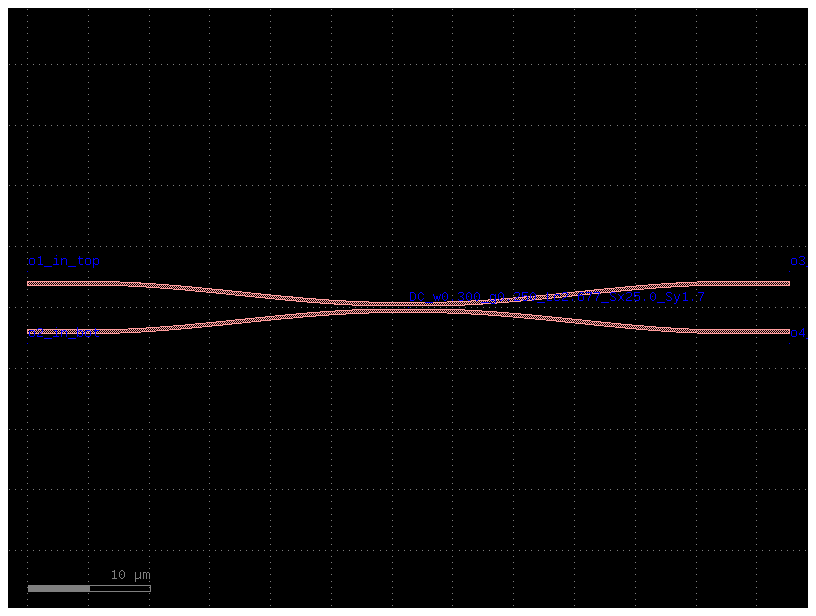

In [5]:
bs = make_tuned_beam_splitter(
    wg_width=wg_width_um,
    gap=gap_um,
    coupling_length=coupling_length_um,
    sbend_x=sbend_x_um,
    sbend_y=sbend_y_um,
    input_straight=input_straight_um,
    output_straight=output_straight_um,
    wg_layer=WG_LAYER,
    label_layer=LABEL_LAYER,
    num_sbend_points=num_sbend_points,
    num_straight_points=num_straight_points,
    add_labels=True,
)

bs


bs.plot()

## Write the tuned beam-splitter GDS

In [6]:
bs.write_gds(output_gds_path)

print(f"Saved tuned beam splitter GDS to:")
print(output_gds_path.resolve())

Saved tuned beam splitter GDS to:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\tuned_beam_splitter.gds


## save a parameter record beside the GDS

In [7]:
import json

param_record = {
    "component_name": bs.name,
    "output_gds": str(output_gds_path),
    "wg_width_um": wg_width_um,
    "gap_um": gap_um,
    "coupling_length_um": coupling_length_um,
    "sbend_x_um": sbend_x_um,
    "sbend_y_um": sbend_y_um,
    "input_straight_um": input_straight_um,
    "output_straight_um": output_straight_um,
    "wg_layer": WG_LAYER,
    "label_layer": LABEL_LAYER,
    "notes": (
        "gap_um is edge-to-edge gap in the coupling region. "
        "center-to-center separation is wg_width_um + gap_um."
    ),
}

json_path = GDS_DIR / "tuned_beam_splitter_parameters.json"

with open(json_path, "w") as f:
    json.dump(param_record, f, indent=4)

print(f"Saved parameter record to:")
print(json_path.resolve())

Saved parameter record to:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\tuned_beam_splitter_parameters.json
